# Gradient Boosting

__Index__

__Introduction__

- Gradient-boosted trees consists in an algorithm that ensembles the predictions of weker prediction models, particularly decision trees. Each of these predictors will correct their predecessor. Unlike many algorithms, this one doesn't just deal with improving weights at each iteration, instead tries to learn frrom the previous predictors residual errors and fit the following predictor to those.
- This algorithm can be seen as an optimization one based on a certain loss function. 

## 1. Gradient Tree Boosting (GTB) in Scikit learn

- Scikit-learn (0.21) provides us with two options to implement this algorithm (they are availabl both for classification and regression, but we will only focus on the regression ones), both of them inspired by LightGBM:
    - __'HistGradientBoostingRegressor'__ and
    - __'GradientBoostingRegressor'__
- An interesting detail about this implementations is that they support missing values and for the __'HistGradientBoostingRegressor'__ one categorical data is supported aswell. 
- For small datasets, the use of bins might contribute to very close split points, ence why, in this case, __'GradientBoostingRegressor'__ is preferible. However, our dataset granularity is moderatly high and, as indicated by the official documentation, for a sample with tens of thousands of samples, __'HistGradientBoostingRegressor'__ is preferible. 
- In addition, __'HistGradientBoostingRegressor'__ has the advantage of increased time efficiency and complexity (that will be later on explained in the notebook) compared to __'GradientBoostingRegressor'__. However, the former does not natively support some features of the latter. 

Note: all of these informations are available at the scikit learn documentation.

## 2. Understanding __'HistGradientBoostingRegressor'__

- We decided to use this algorithm because of the infra citated reasons as well as because of the reasons citated in ths section. 

### 2.1. Further Investigating why this approch is faster

### 2.2. Missing Values and Categorical Features Support 

### 2.3. Sample Weights

### 2.4. Parameters

### 2.5. Constraints

## 3. General data loading and setup

In [22]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import KFold, ParameterSampler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, mean_absolute_percentage_error
import os
from sklearn.feature_selection import SelectFromModel

In [8]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# at this point, this are all the features in use 
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness

X shape: (75973, 10)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


## 4. Model performaance with full set of features (previously decided to use)

### 4.1. Without Feature Selection 

In [ ]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8 
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 15
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] 
best_rmse = np.inf 
best_config = None 

# --- NOVO: Configuração da Pasta de Logs ---
log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)  # Cria a pasta se não existir
log_filename = "gb_complete_nofs_log.txt"
log_path = os.path.join(log_dir, log_filename)
# -------------------------------------------

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas (Validation)
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        # Listas para métricas (Train)
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules (Stateless)
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            owners_state = fit_previous_owners_imputer(X_train, "previousOwners", "year", "mileage")
            X_train = transform_previous_owners_imputer(X_train, state=owners_state)
            X_val   = transform_previous_owners_imputer(X_val,   state=owners_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final ---
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # =========================================================
            # LOG DAS FEATURES (Imprimir 1 vez por config)
            # =========================================================
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            # =========================================================
            
            # --- E) Treino ---
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # --- F) Previsões ---
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # --- G) Métricas Detalhadas ---
            
            # 1. TRAIN Metrics
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            # 2. VALIDATION Metrics
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # LOG ATUALIZADO (ORDEM: R2, RMSE, MAE, BIAS)
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            # Store per fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            # Validation
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            # Train
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            # Robustness
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/gb_complete_nofs_log.txt
# =============================

######## CONFIG 1/15 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Used (16): ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'previousOwners', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9569 | RMSE: 2029 | MAE: 1243 | Bias: 5.5
  > [VAL]   R2: 0.9531 | RMSE: 2060 | MAE: 1335 | Bias: -42.2

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9596 | RMSE: 1959 | MAE: 1260 | Bias: 0.6
  > [VAL]   R2: 0.9467 | RMSE: 2236 | MAE: 1382 | Bias: -17.8

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9601 | RMSE: 1946 | MAE: 1

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
12,13,0.10,600,2139.437464,1285.319241,0.951549,0.969817,0.994902
5,6,0.05,600,2146.768702,1291.557880,0.951225,0.968187,4.195008
1,2,0.05,800,2147.673067,1301.432953,0.951200,0.966731,3.117781
2,3,0.15,800,2163.447932,1285.685389,0.950489,0.970358,2.360534
7,8,0.15,600,2173.776488,1307.107284,0.949995,0.966463,4.000936



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}


### 4.2. With Feature Selection 

## 5. Removing Previous owners 

In [17]:
# All of our preprocessing helper functions are in this notebook
%run 05_0_preproc_helpers.ipynb  

# this is the target column - the value we want to predict 
TARGET_COL = "price"  

full_train_dataset = full_train_dataset.drop(columns=['previousOwners']) # in this approach we drop 'previousOwners'
# separate features and target variable from the full training datase
y = full_train_dataset[TARGET_COL].copy()
X = full_train_dataset.drop(columns=[TARGET_COL]).copy()

# at this point, this are all the features in use 
categorical_features = ['Brand', 'model', 'transmission', 'fuelType']              
numeric_features = ['year', 'mileage', 'engineSize', 'tax', 'mpg'] # 'previousOwners' removed from here too 

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Num features:", numeric_features)
print("Cat features:", categorical_features)

N_SPLITS = 8 # the number of folds for K-Fold cross-validation
RANDOM_STATE = 42 # seed to control randomness

X shape: (75973, 9)
y shape: (75973,)
Num features: ['year', 'mileage', 'engineSize', 'tax', 'mpg']
Cat features: ['Brand', 'model', 'transmission', 'fuelType']


### 5.1. Without Feature Selection 

In [11]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8 
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 15
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = [] 
best_rmse = np.inf 
best_config = None 

log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True) 
log_filename = "gb_noprevown_nofs_log.txt"
log_path = os.path.join(log_dir, log_filename)
# -------------------------------------------

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg) 
        log_file.write(msg + "\n") 
        log_file.flush() 

    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas (Validation)
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        # Listas para métricas (Train)
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules (Stateless)
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final ---
            X_train_final = pd.concat([X_train[numeric_features], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features],   X_val_cat],   axis=1)

            # =========================================================
            # LOG DAS FEATURES (Imprimir 1 vez por config)
            # =========================================================
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            # =========================================================
            
            # --- E) Treino ---
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # --- F) Previsões ---
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # --- G) Métricas Detalhadas ---
            
            # 1. TRAIN Metrics
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            # 2. VALIDATION Metrics
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # LOG ATUALIZADO (ORDEM: R2, RMSE, MAE, BIAS)
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            # Store per fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            # Validation
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            # Train
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            # Robustness
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/gb_noprevown_nofs_log.txt
# =============================

######## CONFIG 1/15 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Used (15): ['year', 'mileage', 'engineSize', 'tax', 'mpg', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9550 | RMSE: 2073 | MAE: 1270 | Bias: 5.8
  > [VAL]   R2: 0.9522 | RMSE: 2079 | MAE: 1351 | Bias: -40.8

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9644 | RMSE: 1840 | MAE: 1187 | Bias: 0.6
  > [VAL]   R2: 0.9491 | RMSE: 2185 | MAE: 1337 | Bias: -16.0

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9615 | RMSE: 1913 | MAE: 1211 | Bias: 2.4
 

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
12,13,0.10,600,2107.594167,1265.533899,0.952980,0.971756,2.028987
5,6,0.05,600,2122.235109,1282.597438,0.952346,0.968380,3.148372
13,14,0.10,1000,2129.159638,1302.100528,0.951987,0.966205,-0.313725
1,2,0.05,800,2130.276590,1298.490413,0.951993,0.966042,1.948348
14,15,0.10,600,2138.517628,1268.864198,0.951620,0.969648,1.871188



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}


### 5.2. Without Feature Selection

## 6. Analysing our feature engineering impact

6.1. Age instead of year

In [13]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 20
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []
best_rmse = np.inf
best_config = None

log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "gb_noprevown_age_nofs_log.txt"
log_path = os.path.join(log_dir, log_filename)
# -------------------------------------------

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas (Validation)
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        # Listas para métricas (Train)
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules (Stateless)
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # =========================================================
            # NOVO: TRANSFORMAÇÃO AGE (Inserido no final da limpeza)
            # =========================================================
            # Cria 'age' e remove 'year'. Garante que 'year' já foi usado nos imputers.
            X_train = create_age_and_drop_year(X_train, year_col="year")
            X_val   = create_age_and_drop_year(X_val,   year_col="year")
            
            # Atualiza lista de features para o concat (remove 'year', adiciona 'age')
            # Nota: 'numeric_features' deve estar definida globalmente (lista original)
            numeric_features_curr = [f for f in numeric_features if f != 'year'] + ['age']
            # =========================================================

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final ---
            # IMPORTANTE: Usamos 'numeric_features_curr' que tem 'age' em vez de 'year'
            X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

            # =========================================================
            # LOG DAS FEATURES (Imprimir 1 vez por config)
            # =========================================================
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            # =========================================================
            
            # --- E) Treino ---
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # --- F) Previsões ---
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # --- G) Métricas Detalhadas ---
            
            # 1. TRAIN Metrics
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            # 2. VALIDATION Metrics
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # LOG ATUALIZADO (ORDEM: R2, RMSE, MAE, BIAS)
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            # Store per fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            # Validation
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            # Train
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            # Robustness
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/gb_noprevown_age_nofs_log.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Used (15): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9550 | RMSE: 2073 | MAE: 1270 | Bias: 5.8
  > [VAL]   R2: 0.9522 | RMSE: 2079 | MAE: 1351 | Bias: -40.8

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9644 | RMSE: 1840 | MAE: 1187 | Bias: 0.6
  > [VAL]   R2: 0.9491 | RMSE: 2185 | MAE: 1337 | Bias: -16.0

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9615 | RMSE: 1913 | MAE: 1211 | Bias: 2.

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
12,13,0.10,600,2107.481168,1265.465729,0.952985,0.971756,2.009818
5,6,0.05,600,2122.120959,1282.530711,0.952351,0.968381,3.137377
13,14,0.10,1000,2129.133661,1302.085820,0.951989,0.966206,-0.309291
1,2,0.05,800,2130.244435,1298.461893,0.951994,0.966043,1.944335
15,16,0.10,1000,2130.808279,1279.815626,0.951941,0.969532,2.876221



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}


In [14]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 20
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []
best_rmse = np.inf
best_config = None

log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "gb_noprevown_age_mpy_nofs_log.txt"
log_path = os.path.join(log_dir, log_filename)
# -------------------------------------------

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas (Validation)
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        # Listas para métricas (Train)
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules (Stateless)
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # =========================================================
            # NOVO: TRANSFORMAÇÃO AGE + MILES PER YEAR (Inserido no final)
            # =========================================================
            # Nota: A tua função 'create_age_miles_and_drop_year' já trata da divisão por zero.
            X_train = create_age_miles_and_drop_year(X_train, year_col="year", mileage_col="mileage")
            X_val   = create_age_miles_and_drop_year(X_val,   year_col="year", mileage_col="mileage")
            
            # Atualiza lista de features (sai 'year', entram 'age' e 'miles_per_year')
            numeric_features_curr = [f for f in numeric_features if f != 'year'] + ['age', 'miles_per_year']
            # =========================================================

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final ---
            # Usamos 'numeric_features_curr' que tem 'age' e 'miles_per_year'
            X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

            # =========================================================
            # LOG DAS FEATURES (Imprimir 1 vez por config)
            # =========================================================
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            # =========================================================
            
            # --- E) Treino ---
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # --- F) Previsões ---
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # --- G) Métricas Detalhadas ---
            
            # 1. TRAIN Metrics
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            # 2. VALIDATION Metrics
            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            # LOG ATUALIZADO (ORDEM: R2, RMSE, MAE, BIAS)
            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            # Store per fold
            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            # Validation
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            # Train
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            # Robustness
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# LOG FILE SAVED TO: gb_logs/gb_noprevown_age_mpy_nofs_log.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Used (16): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'miles_per_year', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9553 | RMSE: 2066 | MAE: 1259 | Bias: 6.2
  > [VAL]   R2: 0.9515 | RMSE: 2094 | MAE: 1352 | Bias: -30.2

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9628 | RMSE: 1880 | MAE: 1215 | Bias: 1.1
  > [VAL]   R2: 0.9468 | RMSE: 2235 | MAE: 1367 | Bias: -22.5

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9598 | RMSE: 1952 

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
13,14,0.10,1000,2163.631331,1319.940046,0.950493,0.966174,4.174835
12,13,0.10,600,2164.670050,1297.868894,0.950423,0.970476,4.019135
10,11,0.15,600,2165.027704,1312.967068,0.950386,0.968750,5.170762
1,2,0.05,800,2169.347268,1321.317781,0.950229,0.965394,2.538981
15,16,0.10,1000,2176.545039,1308.000169,0.949866,0.969043,3.248514



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 63, 'max_iter': 1000, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 0}


### 5.3. mpg/enginesize

In [18]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 20
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []
best_rmse = np.inf
best_config = None

log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
log_filename = "gb_noprevown_age_mpy_effi_nofs_log.txt"
log_path = os.path.join(log_dir, log_filename)
# -------------------------------------------

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# FEATURES: Age, Miles/Year, Efficiency | TARGET: Raw Price (No Log)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # =========================================================
            # 1. TRANSFORMAÇÃO AGE + MILES PER YEAR
            # =========================================================
            # Cria 'age', 'miles_per_year' e remove 'year'
            X_train = create_age_miles_and_drop_year(X_train, year_col="year", mileage_col="mileage")
            X_val   = create_age_miles_and_drop_year(X_val,   year_col="year", mileage_col="mileage")
            
            # =========================================================
            # 2. NOVA FEATURE: EFFICIENCY (MPG/Engine)
            # =========================================================
            X_train = create_efficiency_feature(X_train, mpg_col="mpg", engine_col="engineSize")
            X_val   = create_efficiency_feature(X_val,   mpg_col="mpg", engine_col="engineSize")

            # Atualiza lista de features numéricas:
            # - Remove 'year'
            # - Adiciona 'age', 'miles_per_year' e 'efficiency_ratio'
            numeric_features_curr = [f for f in numeric_features if f != 'year'] + ['age', 'miles_per_year', 'efficiency_ratio']
            # =========================================================

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final ---
            # USA numeric_features_curr (com todas as novas features)
            X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

            # Log das features usadas (apenas fold 1)
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            
            # --- E) Treino (SEM LOG, RAW Y) ---
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train)

            # --- F) Previsões ---
            y_pred_train = hgb_model.predict(X_train_final)
            y_pred_val   = hgb_model.predict(X_val_final)

            # --- G) Métricas Detalhadas ---
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# FEATURES: Age, Miles/Year, Efficiency | TARGET: Raw Price (No Log)
# LOG FILE SAVED TO: gb_logs/gb_noprevown_age_mpy_effi_nofs_log.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Used (17): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'miles_per_year', 'efficiency_ratio', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9557 | RMSE: 2055 | MAE: 1262 | Bias: 5.3
  > [VAL]   R2: 0.9517 | RMSE: 2092 | MAE: 1358 | Bias: -31.0

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9622 | RMSE: 1895 | MAE: 1224 | Bias: 1.7
  > [VAL]   R2: 0.9455 | RMSE: 2

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
5,6,0.05,600,2149.051403,1298.787361,0.951152,0.969178,-0.281865
13,14,0.10,1000,2156.336626,1314.747378,0.950799,0.967310,3.095757
12,13,0.10,600,2157.137713,1298.694137,0.950775,0.970259,2.089809
15,16,0.10,1000,2160.270447,1305.550168,0.950642,0.969283,-0.076240
1,2,0.05,800,2167.590132,1321.685565,0.950299,0.965687,2.756302



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': 15, 'learning_rate': 0.05, 'l2_regularization': 2}


the same as before but with log

In [19]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 20
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []
best_rmse = np.inf
best_config = None

log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
# Atualizei o nome para refletir LOG PRICE
log_filename = "gb_noprevown_age_mpy_effi_logprice_nofs_log.txt"
log_path = os.path.join(log_dir, log_filename)
# -------------------------------------------

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log(f"# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)")
    log(f"# FEATURES: Age, Miles/Year, Efficiency | TARGET: Log(Price)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # =========================================================
            # 1. TRANSFORMAÇÃO AGE + MILES PER YEAR
            # =========================================================
            X_train = create_age_miles_and_drop_year(X_train, year_col="year", mileage_col="mileage")
            X_val   = create_age_miles_and_drop_year(X_val,   year_col="year", mileage_col="mileage")
            
            # =========================================================
            # 2. NOVA FEATURE: EFFICIENCY (MPG/Engine)
            # =========================================================
            X_train = create_efficiency_feature(X_train, mpg_col="mpg", engine_col="engineSize")
            X_val   = create_efficiency_feature(X_val,   mpg_col="mpg", engine_col="engineSize")

            # Atualiza lista de features numéricas:
            numeric_features_curr = [f for f in numeric_features if f != 'year'] + ['age', 'miles_per_year', 'efficiency_ratio']
            # =========================================================

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final ---
            X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

            # Log das features usadas (apenas fold 1)
            if fold == 1:
                feature_names = list(X_train_final.columns)
                log(f"  > Features Used ({len(feature_names)}): {feature_names}")
            
            # --- E) Treino (COM LOG TRANSFORM) ---
            # Aplicar Log ao Target para normalizar a distribuição do preço
            y_train_log = np.log1p(y_train)

            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            hgb_model.fit(X_train_final, y_train_log)

            # --- F) Previsões (REVERSÃO DO LOG) ---
            y_pred_train_log = hgb_model.predict(X_train_final)
            y_pred_val_log   = hgb_model.predict(X_val_final)

            # Reverter para escala original (expm1)
            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # --- G) Métricas Detalhadas ---
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            # Validation
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            # Train
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            # Robustness
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

# -----------------------------
# Results
# -----------------------------
results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (DETAILED METRICS: R2, RMSE, MAE, BIAS)
# FEATURES: Age, Miles/Year, Efficiency | TARGET: Log(Price)
# LOG FILE SAVED TO: gb_logs/gb_noprevown_age_mpy_effi_logprice_nofs_log.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Used (17): ['mileage', 'engineSize', 'tax', 'mpg', 'age', 'miles_per_year', 'efficiency_ratio', 'Brand', 'model', 'transmission_AUTOMATIC', 'transmission_MANUAL', 'transmission_SEMIAUTO', 'fuelType_DIESEL', 'fuelType_ELECTRIC', 'fuelType_HYBRID', 'fuelType_OTHER', 'fuelType_PETROL']
  > [TRAIN] R2: 0.9614 | RMSE: 1919 | MAE: 1122 | Bias: 96.3
  > [VAL]   R2: 0.9559 | RMSE: 1997 | MAE: 1277 | Bias: 62.9

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9599 | RMSE: 1950 | MAE: 1187 | Bias: 99.3
  > [VAL]   R2: 0.9482 | RMSE:

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
12,13,0.10,600,2174.230144,1272.439225,0.949972,0.968974,100.260243
15,16,0.10,1000,2180.990870,1273.028118,0.949655,0.968470,100.194568
19,20,0.05,800,2181.641684,1280.546778,0.949631,0.965025,101.239996
5,6,0.05,600,2182.867416,1279.059725,0.949594,0.966391,104.415733
17,18,0.15,800,2184.027111,1287.876519,0.949519,0.964990,101.422785



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}


extra features and fs

In [23]:
class MyRandomForestSelector:
    def __init__(self, n_features=10, n_estimators=300, random_state=42):
        self.n_features = n_features
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.model_ = None
        self.selected_features_ = None

    def fit(self, X: pd.DataFrame, y: pd.Series):
        model = RandomForestRegressor(
            n_estimators=self.n_estimators,
            random_state=self.random_state,
            n_jobs=-1
        )
        model.fit(X, y)

        importances = model.feature_importances_
        idx = importances.argsort()[::-1][:self.n_features]

        self.selected_features_ = X.columns[idx].tolist()
        self.model_ = model

        return self

    def transform(self, X: pd.DataFrame):
        return X[self.selected_features_]


In [24]:
# ---------------------------------------------------------
# 2. CONFIGURAÇÃO DO CROSS-VALIDATION
# ---------------------------------------------------------
N_SPLITS = 8
RANDOM_STATE = 42
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# ---------------------------------------------------------
# 3. HIPERPARÂMETROS
# ---------------------------------------------------------
param_distributions = {
    "max_iter": [600, 800, 1000],
    "learning_rate": [0.05, 0.1, 0.15],
    "max_leaf_nodes": [31, 63, 127],
    "max_depth": [None, 10, 20, 11, 15],
    "l2_regularization": [0, 1, 2, 5],
    "min_samples_leaf": [20, 40]
}

# ---------------------------------------------------------
# 4. CONFIGURAÇÃO DO RANDOM SEARCH
# ---------------------------------------------------------
N_RANDOM_CONFIGS = 20
sampler = ParameterSampler(param_distributions, n_iter=N_RANDOM_CONFIGS, random_state=RANDOM_STATE)

search_results = []
best_rmse = np.inf
best_config = None

log_dir = "gb_logs"
os.makedirs(log_dir, exist_ok=True)
# Nome atualizado para refletir Feature Selection (FS)
log_filename = "gb_noprevown_age_mpy_effi_logprice_WITH_FS_log.txt"
log_path = os.path.join(log_dir, log_filename)

with open(log_path, "w", encoding="utf-8") as log_file:

    def log(msg: str):
        print(msg)
        log_file.write(msg + "\n")
        log_file.flush()

    log("# =============================")
    log(f"# START OF HGB SEARCH (WITH RANDOM FOREST FEATURE SELECTION)")
    log(f"# FEATURES: Age, Miles/Year, Efficiency | TARGET: Log(Price)")
    log(f"# LOG FILE SAVED TO: {log_path}")
    log("# =============================")
    
    for config_id, params in enumerate(sampler, start=1):
        log("")
        log(f"######## CONFIG {config_id}/{N_RANDOM_CONFIGS} ########")
        log(f"Parameters: {params}")

        # Listas para métricas
        fold_rmses_val, fold_maes_val, fold_r2s_val, fold_bias_val = [], [], [], []
        fold_rmses_tr, fold_maes_tr, fold_r2s_tr, fold_bias_tr = [], [], [], []
        fold_med_ae = []

        for fold, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
            
            # --- A) Split Data ---
            X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
            y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

            log(f"\n[C{config_id}|F{fold}] Processing fold...")

            # --- B) Pipeline de Limpeza ---
            year_state = fit_year_median(X_train, year_col="year", model_col="model")
            X_train = transform_year_with_model_median(X_train, state=year_state)
            X_val   = transform_year_with_model_median(X_val,   state=year_state)

            engine_state = fit_engine_size_imputer(X_train, engine_col="engineSize")
            X_train = transform_engine_size_imputer(X_train, state=engine_state)
            X_val   = transform_engine_size_imputer(X_val,   state=engine_state)

            # Tax Custom Rules
            X_train = transform_tax_custom_rules(X_train, "tax", "year", "fuelType", "engineSize")
            X_val   = transform_tax_custom_rules(X_val, "tax", "year", "fuelType", "engineSize")

            mpg_state = fit_mpg_imputer(X_train, mpg_col="mpg", do_abs=True)
            X_train = transform_mpg_imputer(X_train, state=mpg_state)
            X_val   = transform_mpg_imputer(X_val,   state=mpg_state)

            # Resolvers
            brand_state = fit_ambiguous_brand_resolver(X_train, valid_brands)
            X_train, _, _ = transform_ambiguous_brands(X_train, brand_state)
            X_val, _, _   = transform_ambiguous_brands(X_val, brand_state)

            model_state = fit_invalid_model_resolver(X_train, valid_models_by_brand)
            X_train, _, _ = transform_invalid_models(X_train, model_state)
            X_val, _, _   = transform_invalid_models(X_val, model_state)

            transm_state = fit_transmission_resolver(X_train, valid_transmissions)
            X_train, _, _ = transform_transmission_resolver(X_train, transm_state)
            X_val, _, _   = transform_transmission_resolver(X_val, transm_state)
            
            fuel_state = fit_fueltype_resolver(X_train, valid_fueltypes)
            X_train, _, _ = transform_fueltype_resolver(X_train, fuel_state)
            X_val, _, _   = transform_fueltype_resolver(X_val, fuel_state)

            # =========================================================
            # 1. TRANSFORMAÇÃO AGE + MILES PER YEAR
            # =========================================================
            X_train = create_age_miles_and_drop_year(X_train, year_col="year", mileage_col="mileage")
            X_val   = create_age_miles_and_drop_year(X_val,   year_col="year", mileage_col="mileage")
            
            # =========================================================
            # 2. NOVA FEATURE: EFFICIENCY (MPG/Engine)
            # =========================================================
            X_train = create_efficiency_feature(X_train, mpg_col="mpg", engine_col="engineSize")
            X_val   = create_efficiency_feature(X_val,   mpg_col="mpg", engine_col="engineSize")

            # Atualiza lista de features numéricas
            numeric_features_curr = [f for f in numeric_features if f != 'year'] + ['age', 'miles_per_year', 'efficiency_ratio']
            # =========================================================

            # --- C) Encoding ---
            high_card_features = ["Brand", "model"]
            low_card_features  = [c for c in categorical_features if c not in high_card_features]

            te = MyTargetEncoder(smoothing=5)
            te.fit(X_train[high_card_features], y_train)
            X_train_high = te.transform(X_train[high_card_features])
            X_val_high   = te.transform(X_val[high_card_features])

            ohe = MyOneHotEncoder()
            ohe.fit(X_train[low_card_features])
            X_train_low = ohe.transform(X_train[low_card_features])
            X_val_low   = ohe.transform(X_val[low_card_features])

            X_train_cat = pd.concat([X_train_high, X_train_low], axis=1)
            X_val_cat   = pd.concat([X_val_high,   X_val_low],   axis=1)

            # --- D) Matriz Final (Todas as Features) ---
            X_train_final = pd.concat([X_train[numeric_features_curr], X_train_cat], axis=1)
            X_val_final   = pd.concat([X_val[numeric_features_curr],   X_val_cat],   axis=1)

            # --- PREPARAÇÃO DO TARGET (Log) ---
            y_train_log = np.log1p(y_train)

            # =========================================================
            # E) FEATURE SELECTION (Embedded RF)
            # =========================================================
            # Usamos um Random Forest rápido para selecionar as features mais fortes
            selector_model = RandomForestRegressor(
                n_estimators=50, 
                max_depth=10, 
                random_state=42, 
                n_jobs=-1
            )
            
            # 'median' significa que mantemos apenas a metade superior das features (as melhores)
            selector = SelectFromModel(selector_model, threshold="median")
            
            # Fit apenas no TREINO
            selector.fit(X_train_final, y_train_log)
            
            # Transformar os datasets para manter apenas as colunas selecionadas
            X_train_selected = selector.transform(X_train_final)
            X_val_selected   = selector.transform(X_val_final)
            
            # Log das features mantidas
            if fold == 1:
                mask = selector.get_support()
                kept_feats = X_train_final.columns[mask].tolist()
                log(f"  > Features Selected ({len(kept_feats)}/{X_train_final.shape[1]}): {kept_feats}")
            # =========================================================
            
            # --- F) Treino do HGB ---
            hgb_model = HistGradientBoostingRegressor(random_state=RANDOM_STATE, **params)
            
            # IMPORTANTE: Treinamos com os dados filtrados (X_train_selected)
            hgb_model.fit(X_train_selected, y_train_log)

            # --- G) Previsões (REVERSÃO DO LOG) ---
            y_pred_train_log = hgb_model.predict(X_train_selected)
            y_pred_val_log   = hgb_model.predict(X_val_selected)

            y_pred_train = np.expm1(y_pred_train_log)
            y_pred_val   = np.expm1(y_pred_val_log)

            # --- H) Métricas ---
            mae_tr = mean_absolute_error(y_train, y_pred_train)
            rmse_tr = np.sqrt(mean_squared_error(y_train, y_pred_train))
            r2_tr = r2_score(y_train, y_pred_train)
            bias_tr = np.mean(y_train - y_pred_train)

            mae_val = mean_absolute_error(y_val, y_pred_val)
            rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
            r2_val = r2_score(y_val, y_pred_val)
            bias_val = np.mean(y_val - y_pred_val)
            med_ae_val = median_absolute_error(y_val, y_pred_val)

            log(f"  > [TRAIN] R2: {r2_tr:.4f} | RMSE: {rmse_tr:.0f} | MAE: {mae_tr:.0f} | Bias: {bias_tr:.1f}")
            log(f"  > [VAL]   R2: {r2_val:.4f} | RMSE: {rmse_val:.0f} | MAE: {mae_val:.0f} | Bias: {bias_val:.1f}")

            fold_maes_tr.append(mae_tr); fold_rmses_tr.append(rmse_tr); fold_r2s_tr.append(r2_tr); fold_bias_tr.append(bias_tr)
            fold_maes_val.append(mae_val); fold_rmses_val.append(rmse_val); fold_r2s_val.append(r2_val); fold_bias_val.append(bias_val)
            fold_med_ae.append(med_ae_val)

        # Average metrics
        mean_rmse_val = np.mean(fold_rmses_val)
        mean_mae_val  = np.mean(fold_maes_val)
        mean_r2_val   = np.mean(fold_r2s_val)
        mean_bias_val = np.mean(fold_bias_val)
        
        mean_mae_tr   = np.mean(fold_maes_tr)
        mean_r2_tr    = np.mean(fold_r2s_tr)
        mean_bias_tr  = np.mean(fold_bias_tr)
        
        log("")
        log(f"Config {config_id} SUMMARY:")
        log(f"  [TRAIN AVG] MAE: {mean_mae_tr:.1f} | R2: {mean_r2_tr:.4f} | Bias: {mean_bias_tr:.1f}")
        log(f"  [VAL AVG]   MAE: {mean_mae_val:.1f} | R2: {mean_r2_val:.4f} | Bias: {mean_bias_val:.1f} | RMSE: {mean_rmse_val:.1f}")

        search_results.append({
            "config_id": config_id,
            **params,
            "val_rmse": mean_rmse_val,
            "val_mae": mean_mae_val,
            "val_r2": mean_r2_val,
            "val_bias": mean_bias_val,
            "train_mae": mean_mae_tr,
            "train_r2": mean_r2_tr,
            "train_bias": mean_bias_tr,
            "val_med_ae": np.mean(fold_med_ae)
        })

        if mean_rmse_val < best_rmse:
            best_rmse = mean_rmse_val
            best_config = {**params}
            log(f"[NEW BEST RMSE] Config {config_id}")

    log("# END OF SEARCH")

results_df = pd.DataFrame(search_results)
results_df_sorted = results_df.sort_values(by="val_rmse", ascending=True)

print("\nTop 5 Configurations by RMSE:")
cols = ["config_id", "learning_rate", "max_iter", "val_rmse", "val_mae", "val_r2", "train_r2", "val_bias"]
display(results_df_sorted[cols].head(5))

print("\nBest Config found:")
print(best_config)

# =============================
# START OF HGB SEARCH (WITH RANDOM FOREST FEATURE SELECTION)
# FEATURES: Age, Miles/Year, Efficiency | TARGET: Log(Price)
# LOG FILE SAVED TO: gb_logs/gb_noprevown_age_mpy_effi_logprice_WITH_FS_log.txt
# =============================

######## CONFIG 1/20 ########
Parameters: {'min_samples_leaf': 40, 'max_leaf_nodes': 63, 'max_iter': 800, 'max_depth': 11, 'learning_rate': 0.1, 'l2_regularization': 1}

[C1|F1] Processing fold...
  > Features Selected (9/17): ['mileage', 'engineSize', 'mpg', 'age', 'miles_per_year', 'efficiency_ratio', 'Brand', 'model', 'transmission_MANUAL']
  > [TRAIN] R2: 0.9543 | RMSE: 2088 | MAE: 1226 | Bias: 111.3
  > [VAL]   R2: 0.9514 | RMSE: 2097 | MAE: 1332 | Bias: 88.7

[C1|F2] Processing fold...
  > [TRAIN] R2: 0.9609 | RMSE: 1928 | MAE: 1175 | Bias: 99.7
  > [VAL]   R2: 0.9465 | RMSE: 2241 | MAE: 1346 | Bias: 88.8

[C1|F3] Processing fold...
  > [TRAIN] R2: 0.9601 | RMSE: 1947 | MAE: 1166 | Bias: 101.5
  > [VAL]   R2: 0.9456 |

,config_id,learning_rate,max_iter,val_rmse,val_mae,val_r2,train_r2,val_bias
12,13,0.10,600,2202.000041,1289.428719,0.948716,0.967179,103.008494
15,16,0.10,1000,2202.576332,1292.252776,0.948695,0.966241,105.168049
10,11,0.15,600,2205.518681,1296.086738,0.948572,0.967294,101.660533
2,3,0.15,800,2208.703132,1297.070334,0.948436,0.965403,98.695490
14,15,0.10,600,2208.908020,1295.189804,0.948402,0.964532,104.079840



Best Config found:
{'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}



DIAGNÓSTICO DETALHADO DE ERROS
Configuração em teste: {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}

--- TOP 10 MAIORES ERROS (Onde o modelo falhou) ---


,Brand,model,age,mileage,Real_Price,Predicted,Error
2954,MERCEDES,CCLASS,1.0,2270.0,67199,28081.897093,39117.102907
27631,BMW,M4,4.0,4550.0,76990,45864.319849,31125.680151
60517,MERCEDES,CCLASS,1.0,391.0,66899,92735.537722,-25836.537722
49963,MERCEDES,CCLASS,1.0,200.0,88995,64068.728898,24926.271102
11852,MERCEDES,ACLASS,1.0,9.0,48980,25822.279541,23157.720459
10406,AUDI,A5,1.0,2000.0,59995,38089.581104,21905.418896
23887,MERCEDES,CLACLASS,1.0,3600.0,54900,33755.688603,21144.311397
24412,MERCEDES,GLSCLASS,1.0,18273.0,24491,45300.233968,-20809.233968
5977,MERCEDES,ACLASS,3.0,13781.0,79999,59251.146396,20747.853604
34917,MERCEDES,MCLASS,50.0,14000.0,24999,4409.651767,20589.348233


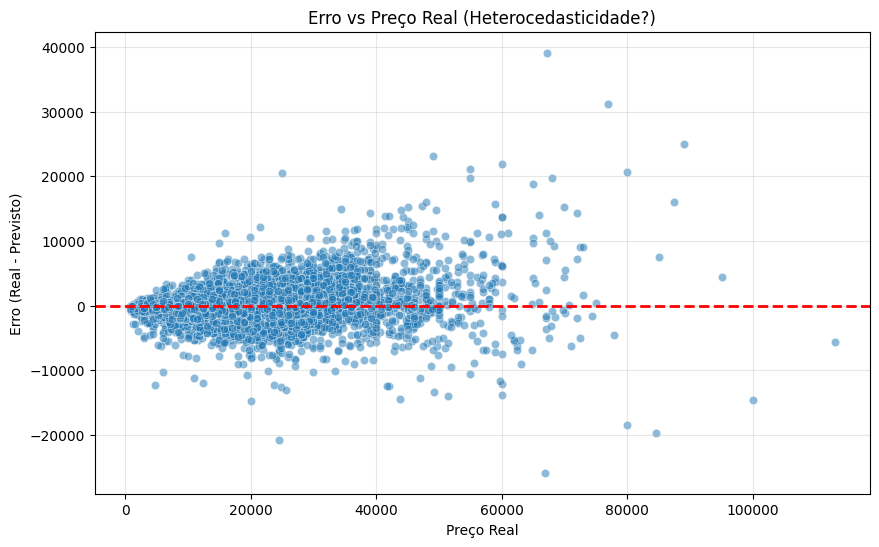

In [25]:
# =========================================================
# 5. DIAGNÓSTICO DE ERROS COM A MELHOR CONFIGURAÇÃO
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

print("\n" + "="*50)
print("DIAGNÓSTICO DETALHADO DE ERROS")
print("Configuração em teste: {'min_samples_leaf': 20, 'max_leaf_nodes': 127, 'max_iter': 600, 'max_depth': None, 'learning_rate': 0.1, 'l2_regularization': 2}")
print("="*50)

# A CONFIGURAÇÃO QUE PEDISTE
specific_config = {
    'min_samples_leaf': 20,
    'max_leaf_nodes': 127,
    'max_iter': 600,
    'max_depth': None,
    'learning_rate': 0.1,
    'l2_regularization': 2
}

# 1. Preparar dados frescos (Split 80/20 simples para teste rápido)
# Nota: Repetimos o pipeline de limpeza aqui para garantir que temos os dados transformados
X_train_diag, X_val_diag, y_train_diag, y_val_diag = train_test_split(X, y, test_size=0.2, random_state=42)

# --- REPETIÇÃO DO PIPELINE DE LIMPEZA (Resumido) ---
# Imputers
year_state = fit_year_median(X_train_diag, "year", "model")
X_train_diag = transform_year_with_model_median(X_train_diag, year_state)
X_val_diag   = transform_year_with_model_median(X_val_diag,   year_state)

eng_state = fit_engine_size_imputer(X_train_diag, "engineSize")
X_train_diag = transform_engine_size_imputer(X_train_diag, eng_state)
X_val_diag   = transform_engine_size_imputer(X_val_diag,   eng_state)

X_train_diag = transform_tax_custom_rules(X_train_diag, "tax", "year", "fuelType", "engineSize")
X_val_diag   = transform_tax_custom_rules(X_val_diag, "tax", "year", "fuelType", "engineSize")

mpg_state = fit_mpg_imputer(X_train_diag, "mpg", do_abs=True)
X_train_diag = transform_mpg_imputer(X_train_diag, mpg_state)
X_val_diag   = transform_mpg_imputer(X_val_diag,   mpg_state)

# Resolvers
brand_state = fit_ambiguous_brand_resolver(X_train_diag, valid_brands)
X_train_diag, _, _ = transform_ambiguous_brands(X_train_diag, brand_state)
X_val_diag, _, _   = transform_ambiguous_brands(X_val_diag, brand_state)

mod_state = fit_invalid_model_resolver(X_train_diag, valid_models_by_brand)
X_train_diag, _, _ = transform_invalid_models(X_train_diag, mod_state)
X_val_diag, _, _   = transform_invalid_models(X_val_diag, mod_state)

trans_state = fit_transmission_resolver(X_train_diag, valid_transmissions)
X_train_diag, _, _ = transform_transmission_resolver(X_train_diag, trans_state)
X_val_diag, _, _   = transform_transmission_resolver(X_val_diag, trans_state)

fuel_state = fit_fueltype_resolver(X_train_diag, valid_fueltypes)
X_train_diag, _, _ = transform_fueltype_resolver(X_train_diag, fuel_state)
X_val_diag, _, _   = transform_fueltype_resolver(X_val_diag, fuel_state)

# Features: Age, Miles, Efficiency
X_train_diag = create_age_miles_and_drop_year(X_train_diag, "year", "mileage")
X_val_diag   = create_age_miles_and_drop_year(X_val_diag,   "year", "mileage")

X_train_diag = create_efficiency_feature(X_train_diag, "mpg", "engineSize")
X_val_diag   = create_efficiency_feature(X_val_diag,   "mpg", "engineSize")

curr_feats = [f for f in numeric_features if f != 'year'] + ['age', 'miles_per_year', 'efficiency_ratio']

# Encoding
te_diag = MyTargetEncoder(smoothing=5)
te_diag.fit(X_train_diag[["Brand", "model"]], y_train_diag)
X_tr_high = te_diag.transform(X_train_diag[["Brand", "model"]])
X_val_high = te_diag.transform(X_val_diag[["Brand", "model"]])

ohe_diag = MyOneHotEncoder()
low_card = [c for c in categorical_features if c not in ["Brand", "model"]]
ohe_diag.fit(X_train_diag[low_card])
X_tr_low = ohe_diag.transform(X_train_diag[low_card])
X_val_low = ohe_diag.transform(X_val_diag[low_card])

# Matriz Final
X_final_tr = pd.concat([X_train_diag[curr_feats], X_tr_high, X_tr_low], axis=1)
X_final_val = pd.concat([X_val_diag[curr_feats], X_val_high, X_val_low], axis=1)

# Feature Selection (Aplicamos também aqui para ser consistente com o teu loop)
selector_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
selector = SelectFromModel(selector_model, threshold="median")
selector.fit(X_final_tr, np.log1p(y_train_diag)) # Fit com log

X_final_tr_sel = selector.transform(X_final_tr)
X_final_val_sel = selector.transform(X_final_val)

# --- TREINO FINAL ---
final_model = HistGradientBoostingRegressor(random_state=42, **specific_config)
final_model.fit(X_final_tr_sel, np.log1p(y_train_diag)) # Treino com LOG

# Previsão
preds_log = final_model.predict(X_final_val_sel)
preds = np.expm1(preds_log) # Reverter LOG

# =========================================================
# ANÁLISE DOS ERROS
# =========================================================
residuals = y_val_diag - preds
abs_residuals = np.abs(residuals)

# 1. Tabela TOP 10 ERROS
results_df = X_val_diag.copy()
results_df['Real_Price'] = y_val_diag
results_df['Predicted'] = preds
results_df['Error'] = residuals
results_df['Abs_Error'] = abs_residuals

print("\n--- TOP 10 MAIORES ERROS (Onde o modelo falhou) ---")
cols_show = ['Brand', 'model', 'age', 'mileage', 'Real_Price', 'Predicted', 'Error']
display(results_df.sort_values(by='Abs_Error', ascending=False)[cols_show].head(10))

# 2. Gráfico de Resíduos
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_val_diag, y=residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--', lw=2)
plt.title("Erro vs Preço Real (Heterocedasticidade?)")
plt.xlabel("Preço Real")
plt.ylabel("Erro (Real - Previsto)")
plt.grid(True, alpha=0.3)
plt.show()